# The fast path: one compiled graph from photometry to posteriors

Every `fit_*` call so far pays Python-loop and retrace overhead per star.
`make_hmc_pipeline` removes all of it: window adaptation, kernel, and the
sampling scan trace into **one XLA program** with the observed magnitudes as a
traced argument —

```
pipeline(key, mags) -> ({teff, logg, feh, mu} posterior samples, diagnostics)
```

The compile is paid once; each additional star is pure device execution. And
because the pipeline is a pure JAX function, `jax.vmap` turns it into a
**catalog engine**: every star sampled in a single XLA call.

Grid: the real TSLTE table (notebook 03). Sampler: HMC with fixed
integration length — cheaper per step than NUTS (no tree doubling), and the
mass-matrix adaptation handles the parameter scales.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import StarModel, fit_nss, load_photometry_grid, make_hmc_pipeline

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(23)

DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

## 1. Model, priors, and the two-argument likelihood

The likelihood takes the data as an argument — that is what lets one compiled
program serve every star.

In [2]:
grid = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")
model = StarModel(grid=grid, interp_method="pchip")
SIG_MAG = 0.02

priors = {
    "teff": Uniform(float(grid.axes[0][0]), float(grid.axes[0][-1])),
    "logg": Uniform(float(grid.axes[1][0]), float(grid.axes[1][-1])),
    "feh": Uniform(float(grid.axes[2][0]), float(grid.axes[2][-1])),
    "mu": Uniform(-28.0, -8.0),
}


def loglikelihood(p, mags):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return -0.5 * jnp.sum(((pred - mags) / SIG_MAG) ** 2)


pipeline = make_hmc_pipeline(
    loglikelihood, priors, num_warmup=500, num_samples=1000, num_integration_steps=32
)

## 2. Single star: compile once, then pure device execution

In [3]:
truth = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -18.0}
mags_obs = jnp.asarray(
    np.asarray(model.predict_mags(**truth)) + rng.normal(0.0, SIG_MAG, len(grid.filter_names))
)

### The arithmetic first: microseconds per evaluation × evaluations per posterior

A single grid-lookup likelihood *is* microseconds. A posterior is not one
evaluation: HMC below does (500 warmup + 1000 samples) × 32 leapfrog steps
= 48,000 *gradient* evaluations (each ~2–3× a forward call). Multiply it out
and the sampler is compute-bound, not overhead-bound.

In [4]:
single_eval = jax.jit(lambda p: loglikelihood(p, mags_obs))
p_example = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -18.0}
_ = jax.block_until_ready(single_eval(p_example))  # compile

# Keep the vmap batch small: the separable interpolation materializes a
# (batch, n_logg, n_feh, n_filters) intermediate, so a 100k-wide vmap would
# allocate ~26 GB on this grid. 2k × 10 repeats measures the same number.
N_EVAL = 2_000
p_batch = {
    "teff": np.random.uniform(4000, 6500, N_EVAL),
    "logg": np.random.uniform(0.5, 4.5, N_EVAL),
    "feh": np.random.uniform(-3.5, -0.5, N_EVAL),
    "mu": np.random.uniform(-20, -16, N_EVAL),
}
batch_eval = jax.jit(jax.vmap(lambda p: loglikelihood(p, mags_obs)))
_ = jax.block_until_ready(batch_eval(p_batch))  # compile
t0 = time.time()
for _rep in range(10):
    _ = jax.block_until_ready(batch_eval(p_batch))
per_eval_us = (time.time() - t0) / (10 * N_EVAL) * 1e6

n_grad_evals = (500 + 1000) * 32
print(f"single likelihood evaluation: {per_eval_us:.1f} µs (amortized, vmapped)")
print(
    f"HMC posterior = {n_grad_evals:,} gradient evals × ~2.5 × {per_eval_us:.1f} µs"
    f" ≈ {n_grad_evals * 2.5 * per_eval_us / 1e6:.1f} s predicted"
)

single likelihood evaluation: 12.8 µs (amortized, vmapped)
HMC posterior = 48,000 gradient evals × ~2.5 × 12.8 µs ≈ 1.5 s predicted


In [5]:
t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(0), mags_obs))
t_cold = time.time() - t0

t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(1), mags_obs))
t_warm = time.time() - t0

print(f"cold (with XLA compile): {t_cold:5.1f} s")
print(f"warm (pure execution):   {t_warm:5.2f} s/star")
print(f"acceptance {float(info['acceptance_rate']):.2f}, {int(info['num_divergent'])} divergences")
for n in priors:
    q = np.percentile(np.asarray(samples[n]), [16, 50, 84])
    print(f"  {n:5s} truth {truth[n]:9.2f}:  {q[1]:9.2f}  68% [{q[0]:9.2f}, {q[2]:9.2f}]")

cold (with XLA compile):   4.4 s
warm (pure execution):    3.64 s/star
acceptance 0.95, 0 divergences
  teff  truth   4600.00:    4633.38  68% [  4601.69,   4671.05]
  logg  truth      2.00:       1.79  68% [     1.50,      2.08]
  feh   truth     -1.50:      -1.48  68% [    -1.59,     -1.37]
  mu    truth    -18.00:     -17.96  68% [   -18.00,    -17.91]


## 3. Catalog mode: vmap over 100 stars, one XLA call

In [6]:
N_STARS = 100
truths = {
    "teff": rng.uniform(4000.0, 6500.0, N_STARS),
    "logg": rng.uniform(1.0, 4.5, N_STARS),
    "feh": rng.uniform(-3.5, -0.5, N_STARS),
    "mu": np.full(N_STARS, -18.0),
}
clean = np.stack(
    [
        np.asarray(
            model.predict_mags(
                teff=truths["teff"][i],
                logg=truths["logg"][i],
                feh=truths["feh"][i],
                mu=truths["mu"][i],
            )
        )
        for i in range(N_STARS)
    ]
)
mags_batch = jnp.asarray(clean + rng.normal(0.0, SIG_MAG, clean.shape))
keys = jax.random.split(jax.random.PRNGKey(3), N_STARS)

catalog_pipeline = jax.jit(jax.vmap(pipeline))

t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_cold = time.time() - t0
t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_warm = time.time() - t0

print(f"catalog of {N_STARS} stars, full HMC posteriors each:")
print(f"  cold (compile): {t_cat_cold:6.1f} s")
print(f"  warm:           {t_cat_warm:6.1f} s  →  {t_cat_warm / N_STARS * 1000:.0f} ms/star")
print(f"  median acceptance: {float(jnp.median(cat_info['acceptance_rate'])):.2f}")

catalog of 100 stars, full HMC posteriors each:
  cold (compile):  149.8 s
  warm:            171.0 s  →  1710 ms/star
  median acceptance: 0.95


## 4. Catalog recovery

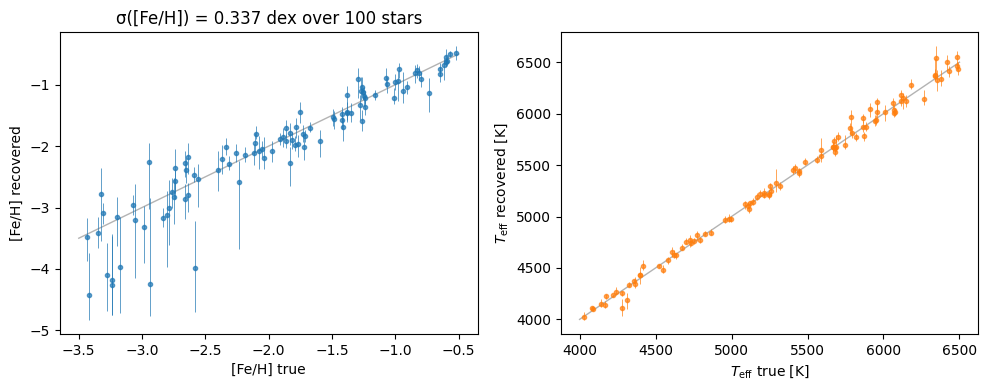

In [7]:
feh_med = np.median(np.asarray(cat_samples["feh"]), axis=1)
feh_lo, feh_hi = np.percentile(np.asarray(cat_samples["feh"]), [16, 84], axis=1)
teff_med = np.median(np.asarray(cat_samples["teff"]), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar(
    truths["feh"],
    feh_med,
    yerr=[feh_med - feh_lo, feh_hi - feh_med],
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
)
axes[0].plot([-3.5, -0.5], [-3.5, -0.5], color="0.7", lw=1, zorder=0)
scatter = np.std(feh_med - truths["feh"])
axes[0].set(
    xlabel="[Fe/H] true",
    ylabel="[Fe/H] recovered",
    title=f"σ([Fe/H]) = {scatter:.3f} dex over {N_STARS} stars",
)
axes[1].errorbar(
    truths["teff"],
    teff_med,
    yerr=np.abs(np.percentile(np.asarray(cat_samples["teff"]), [16, 84], axis=1) - teff_med),
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
    color="C1",
)
axes[1].plot([4000, 6500], [4000, 6500], color="0.7", lw=1, zorder=0)
axes[1].set(xlabel=r"$T_{\rm eff}$ true [K]", ylabel=r"$T_{\rm eff}$ recovered [K]")
plt.tight_layout()
plt.show()

## 5. Cross-check against NSS on one star

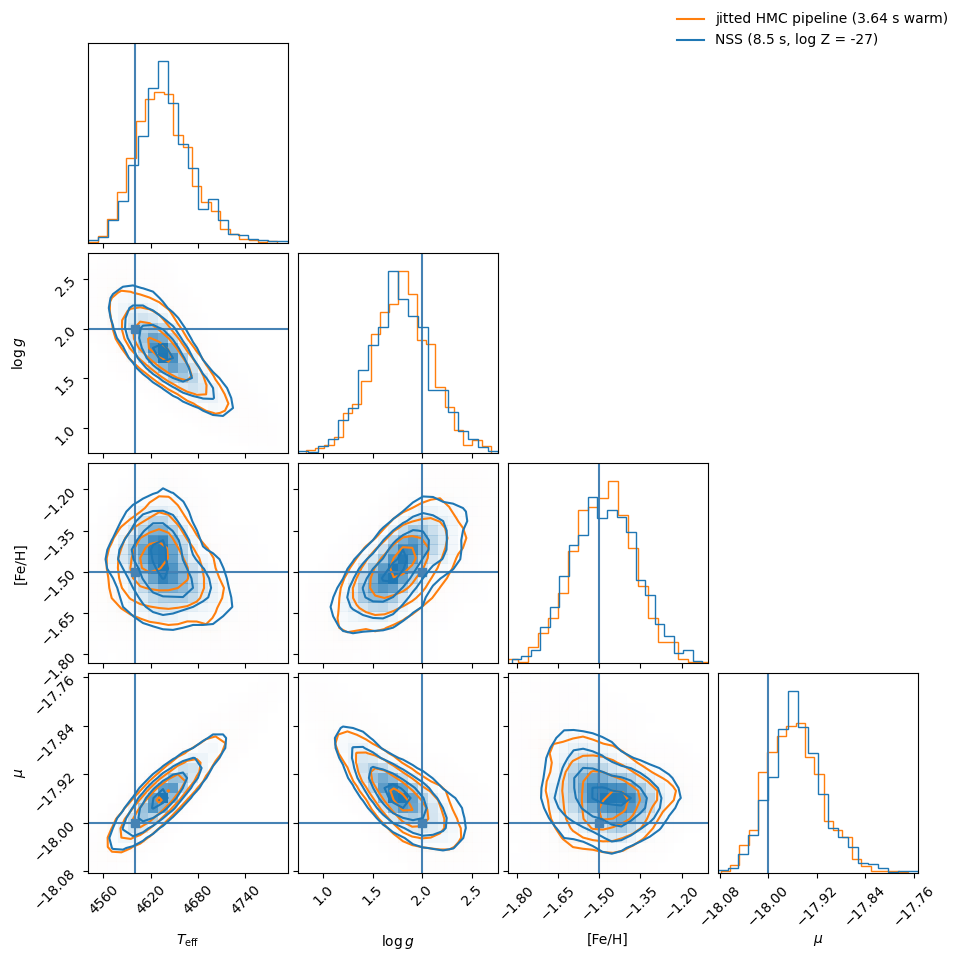

In [8]:
t0 = time.time()
nss = fit_nss(
    loglikelihood, priors, key=jax.random.PRNGKey(4), data=mags_obs, n_live=400, num_delete=40
)
t_nss = time.time() - t0

names = list(priors)
stack_hmc = np.column_stack([np.asarray(samples[n]) for n in names])
stack_nss = np.column_stack([np.asarray(nss.samples[n]) for n in names])
fig = corner.corner(
    stack_hmc,
    labels=[r"$T_{\rm eff}$", r"$\log g$", "[Fe/H]", r"$\mu$"],
    truths=[truth[n] for n in names],
    color="C1",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
corner.corner(
    stack_nss,
    fig=fig,
    color="C0",
    hist_kwargs={"density": True},
    plot_datapoints=False,
    smooth=1.0,
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C1", label=f"jitted HMC pipeline ({t_warm:.2f} s warm)"),
        plt.Line2D([], [], color="C0", label=f"NSS ({t_nss:.1f} s, log Z = {nss.logz:.0f})"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()

## 6. Jitted NSS: the whole nested run in one graph too

`fit_nss` drives the sampler from a Python loop that pulls the evidence
stopping criterion to the host every iteration — hundreds of device
round-trips per star. `make_nss_pipeline` moves the loop into
`lax.while_loop` (criterion evaluated on-device, dead particles scattered
into a preallocated buffer): one graph, one launch, vmap-able core.

In [9]:
from tengri_stars import make_nss_pipeline

nss_pipe = make_nss_pipeline(loglikelihood, priors, n_live=400, num_delete=40)

t0 = time.time()
s_nss, i_nss = nss_pipe(jax.random.PRNGKey(6), mags_obs)
t_nss_cold = time.time() - t0
t0 = time.time()
s_nss, i_nss = nss_pipe(jax.random.PRNGKey(7), mags_obs)
t_nss_warm = time.time() - t0

print(f"jitted NSS cold (compile): {t_nss_cold:5.1f} s")
print(f"jitted NSS warm:           {t_nss_warm:5.2f} s/star")
print(
    f"  log Z = {i_nss['logz']:.1f} (python-loop fit_nss gave {nss.logz:.1f}), "
    f"ESS = {i_nss['ess']:.0f}, {i_nss['n_iterations']} iterations"
)

jitted NSS cold (compile):   6.7 s
jitted NSS warm:            4.17 s/star
  log Z = -26.2 (python-loop fit_nss gave -26.8), ESS = 1960, 202 iterations


Catalog NSS on CPU: reuse the one compiled core sequentially. (`jax.vmap` of
`nss_pipe.run` also works and is the GPU story — but the slice-sampler's XLA
graph is large, and the vmapped compile ballooned past 10 GB RSS on this
machine; a 10 GB OOM watchdog killed it. Sequential reuse of the jitted core
is the honest CPU pattern.)

In [10]:
N_NSS = 10
keys_nss = jax.random.split(jax.random.PRNGKey(8), N_NSS)
t0 = time.time()
logzs = [nss_pipe(keys_nss[i], mags_batch[i])[1]["logz"] for i in range(N_NSS)]
t_nss_cat = time.time() - t0
print(
    f"sequential jitted NSS over {N_NSS} stars: {t_nss_cat:.1f} s → {t_nss_cat / N_NSS:.2f} s/star"
)

sequential jitted NSS over 10 stars: 60.5 s → 6.05 s/star


## 7. Timing summary

In [11]:
print("timing summary (this machine, CPU):")
print(f"  single likelihood evaluation   {per_eval_us:8.1f} µs")
print(f"  HMC pipeline, single star      {t_warm:8.2f} s")
print(f"  HMC pipeline, catalog vmap     {t_cat_warm / N_STARS:8.2f} s/star")
print(f"  jitted NSS, single star        {t_nss_warm:8.2f} s")
print(f"  jitted NSS, catalog (seq.)     {t_nss_cat / N_NSS:8.2f} s/star")
print(f"  python-loop NSS (fit_nss)      {t_nss:8.2f} s")

timing summary (this machine, CPU):
  single likelihood evaluation       12.8 µs
  HMC pipeline, single star          3.64 s
  HMC pipeline, catalog vmap         1.71 s/star
  jitted NSS, single star            4.17 s
  jitted NSS, catalog (seq.)         6.05 s/star
  python-loop NSS (fit_nss)          8.48 s


## When to use which

- **Jitted HMC pipeline**: the throughput path — catalogs, well-constrained
  stars (many bands / CaHK / joint spectra), unimodal posteriors. Milliseconds
  per star once compiled.
- **NSS**: the robustness path — dwarf/giant bimodality (notebook 04),
  evidence for model comparison, no gradients needed. Seconds per star.
- A production MAGIC-scale strategy: jitted pipeline for everything, NSS
  re-runs for stars flagged multimodal (low acceptance, suspicious χ²,
  parallax–photometry tension).